**Cell 1 — Imports and configuration**

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t as t_dist

OUTPUT_DIR = os.getcwd()

RHO_VALUES = np.round(np.arange(-0.8, 0.9, 0.2), 1)
V_RANGE = np.arange(0.5, 0.9999, 0.001)
DOF = 3

**Cell 2 — Compute lambda_U(v) for t-copula**

In [2]:
def upper_tail_dependence_t_copula(v, rho, dof):
    q = t_dist.ppf(v, dof)
    arg = np.sqrt((dof + 1) / (dof / q**2 + 1)) * np.sqrt((1 - rho) / (1 + rho))
    lam = 2 * (1 - t_dist.cdf(arg, dof + 1))

    # Analytical limit at v=1: q -> +inf, so dof/q**2 -> 0
    arg_at_1 = np.sqrt((dof + 1) * (1 - rho) / (1 + rho))
    lam_at_1 = 2 * (1 - t_dist.cdf(arg_at_1, dof + 1))

    v_full = np.append(v, 1.0)
    lam_full = np.append(lam, lam_at_1)
    return v_full, lam_full

curves = {rho: upper_tail_dependence_t_copula(V_RANGE, rho, DOF) for rho in RHO_VALUES}

**Cell 3 — Plot**

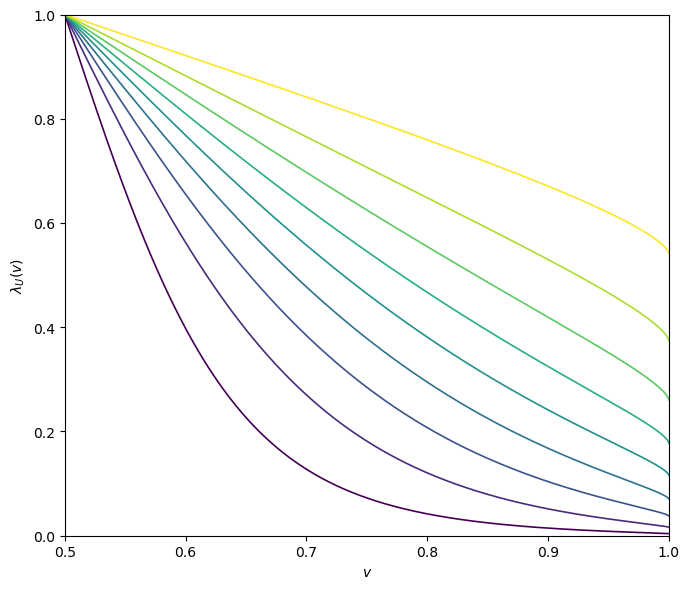

In [4]:
fig, ax = plt.subplots(figsize=(7, 6))

colors = plt.cm.viridis(np.linspace(0, 1, len(RHO_VALUES)))

for color, (rho, (v_full, lam_full)) in zip(colors, curves.items()):
    ax.plot(v_full, lam_full, color=color, linewidth=1.2, label=rf"$\rho = {rho:.1f}$")

ax.set_xlabel(r"$v$")
ax.set_ylabel(r"$\lambda_U(v)$")
ax.set_xlim(0.5, 1.0)
ax.set_ylim(0, 1.0)
ax.grid(False)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "lambda_U_t_copula.png"),
            dpi=200, transparent=True, bbox_inches="tight")
plt.show()